**K-means Clustering**

In [122]:
#importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
#code to choose file upload from system
from google.colab import files
uploaded = files.upload()


Saving fish.csv to fish (4).csv


In [124]:
#reading the CSV file
data= pd.read_csv('fish.csv',header=None)
data.head()

,0,1,2,3,4,5,6
0,Bream,242.0,23.2,25.4,30.0,38.4,13.4
1,Bream,290.0,24.0,26.3,31.2,40.0,13.8
2,Bream,340.0,23.9,26.5,31.1,39.8,15.1
3,Bream,363.0,26.3,29.0,33.5,38.0,13.3
4,Bream,430.0,26.5,29.0,34.0,36.6,15.1


In [125]:
#Adding titles to the columns
data.columns=['Species','Weight','Length1','Length2','Length3','Height','Width']
data.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,38.4,13.4
1,Bream,290.0,24.0,26.3,31.2,40.0,13.8
2,Bream,340.0,23.9,26.5,31.1,39.8,15.1
3,Bream,363.0,26.3,29.0,33.5,38.0,13.3
4,Bream,430.0,26.5,29.0,34.0,36.6,15.1


In [126]:
#cheching for null values
data.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [127]:
#defining x
x= data[['Height','Width']]
x

,Height,Width
0,38.4,13.4
1,40.0,13.8
2,39.8,15.1
3,38.0,13.3
4,36.6,15.1
...,...,...
80,16.2,11.2
81,17.9,11.7
82,15.0,9.6
83,15.0,9.6


In [128]:
#import kmeans cluster algorithm from sklearn
from sklearn.cluster import KMeans
#evaluating optimal number of cluster
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10, random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)


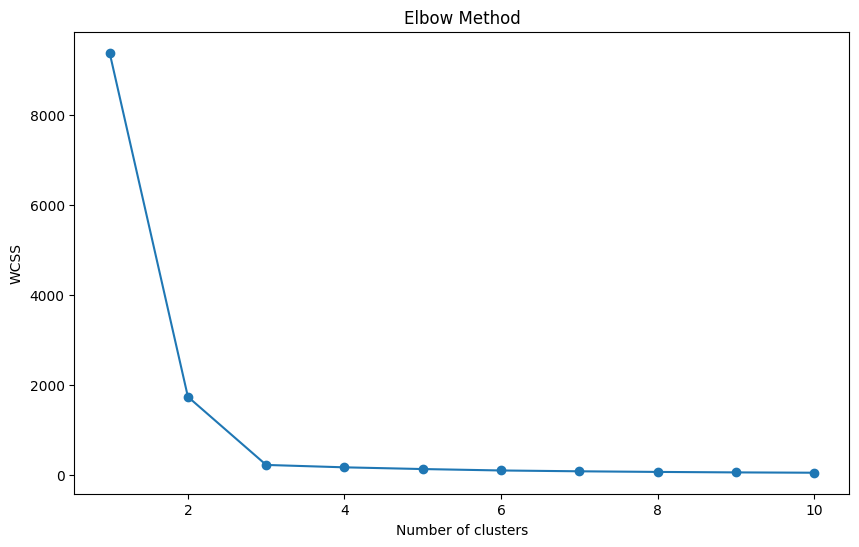

In [129]:
#elbow method to find the optimal number of clusters
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [130]:
#applying k means clusting with optimal number of clusters
kmeans=KMeans(n_clusters=3, init='k-means++',max_iter=300,n_init=10,random_state=0)
y_kmeans=kmeans.fit_predict(x)

In [131]:
y_kmeans


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [132]:
#showing the cluster in the dataset
data['Cluster']=y_kmeans


In [133]:
data.head()


,Species,Weight,Length1,Length2,Length3,Height,Width,Cluster
0,Bream,242.0,23.2,25.4,30.0,38.4,13.4,2
1,Bream,290.0,24.0,26.3,31.2,40.0,13.8,2
2,Bream,340.0,23.9,26.5,31.1,39.8,15.1,2
3,Bream,363.0,26.3,29.0,33.5,38.0,13.3,2
4,Bream,430.0,26.5,29.0,34.0,36.6,15.1,2


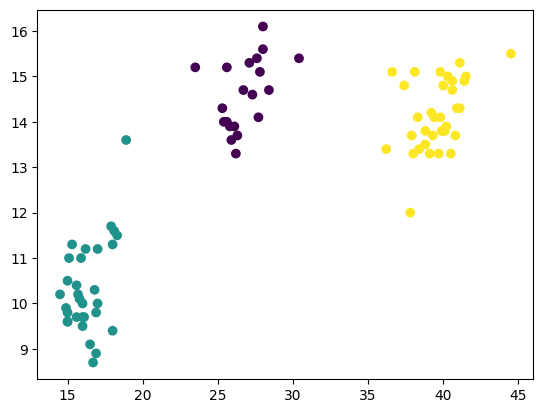

In [134]:
#scatter plot to visualize the clusters formed
plt.scatter(x['Height'],x['Width'],c=y_kmeans)
plt.show()

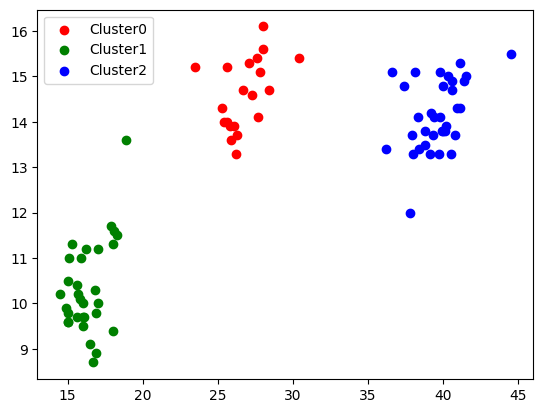

In [135]:
#assinging the label and color to the visualization
colors=['r','g','b']

for i in range(3):
  cluster_data=x[y_kmeans==i]
  plt.scatter(cluster_data['Height'],cluster_data['Width'],
              c=colors[i],label=f'Cluster{i}')
plt.legend()
plt.show()

In [136]:
#function to predict for new speceis
def predict_cluster(Height,Width):
  new_data=[[Height,Width]]
  cluster=kmeans.predict(new_data)
  return cluster[0]

In [137]:
#predict for new values
new_height=38
new_width=13.3
predicted_cluster=predict_cluster(new_height,new_width)
print(f"The species belongs to cluster:{predicted_cluster}")

The species belongs to cluster:2


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [138]:
#check the quality of the clustering
from sklearn.metrics import silhouette_score

In [139]:
silhouette_score(x,y_kmeans)

0.8248956214225807

Here the value is closer to 1. Each cluster is far away from neighbouring cluster and belongs to its own   cluster.                                                                                                                                

**Agglomerative Clustering**

In [140]:
#defining x1
x1= data.iloc[:,[5,6]].values
type(x1)

numpy.ndarray

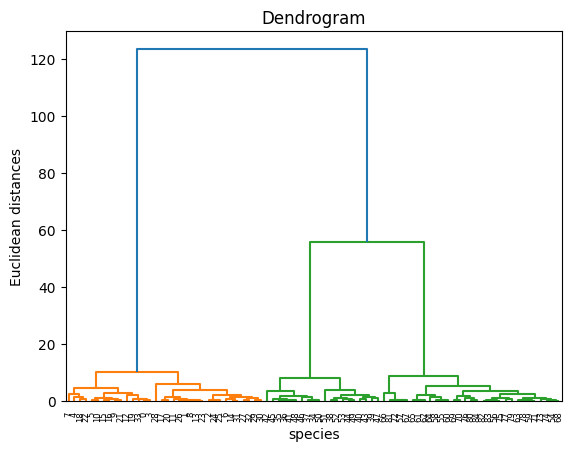

In [141]:
#drawing the dendrogram
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(x1,method='ward'))
plt.title('Dendrogram')
plt.xlabel('species')
plt.ylabel('Euclidean distances')
plt.show()

In [142]:
#importing agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=3,affinity='euclidean',linkage='ward')
y_hc=hc.fit_predict(x1)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [143]:
y_hc

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

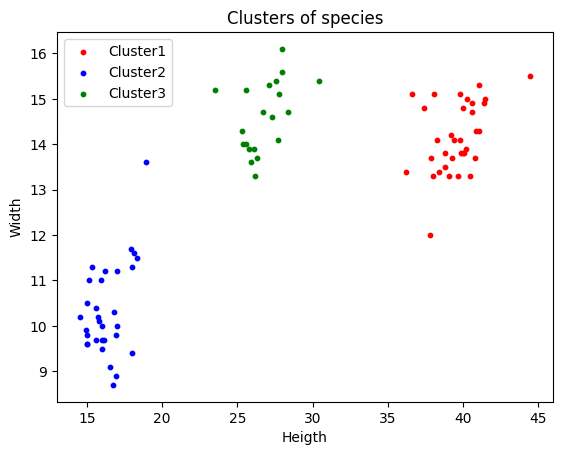

In [144]:
#ploting clusters
plt.scatter(x1[y_hc==0,0],x1[y_hc==0,1],s=10,c='red',label='Cluster1')

plt.scatter(x1[y_hc==1,0],x1[y_hc==1,1],s=10,c='blue',label='Cluster2')

plt.scatter(x1[y_hc==2,0],x1[y_hc==2,1],s=10,c='green',label='Cluster3')

plt.title('Clusters of species')
plt.xlabel('Heigth')
plt.ylabel('Width')
plt.legend()
plt.show()

In [145]:
silhouette_score(x1,y_hc)

0.8248956214225807

**Here the value is closer to 1. Each cluster is far away from neighbouring cluster and belongs to its own cluster.**